In [1]:
import pandas as pd
from functions.functions import corr_heatmap_xy, create_t_shifted_columns

In [2]:
end_year = 2024
region_analysis = "Japan"
shift_period = 12  # Change this to any period you want
golden_data = "v_2A"

Japan_universe = pd.read_csv(f"../data/Global_Universe/Global_Universe_{region_analysis}_{end_year}.csv")

signal_columns = Japan_universe.columns[29:33]
accounting_columns = list(Japan_universe.columns[15:24])


Japan_universe, accounting_columns_t = create_t_shifted_columns(
    Japan_universe,
    accounting_columns,
    shift_period,
)

In [3]:
#drop NAN
corr_columns = list(dict.fromkeys([*signal_columns, *accounting_columns, *accounting_columns_t]))
Japan_universe = Japan_universe.dropna(subset=corr_columns)

# Spearman Correlation

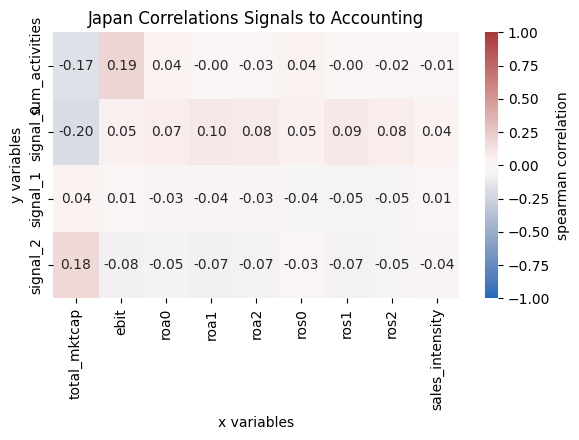

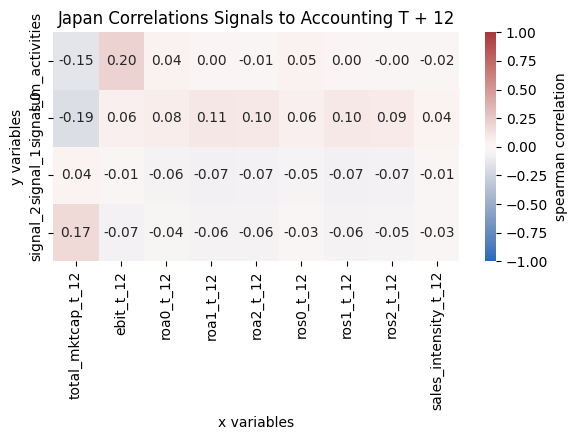

In [4]:
# Spearman version (rank correlation) for Japan only
corr_xy, ax = corr_heatmap_xy(
    Japan_universe,
    y_vars=signal_columns,
    x_vars=accounting_columns,
    method="spearman",
    title="Japan Correlations Signals to Accounting",
)

corr_blocks_spearman = {"Japan": corr_xy}

# Spearman version (rank correlation) for Japan only
corr_xy, ax = corr_heatmap_xy(
    Japan_universe,
    y_vars=signal_columns,
    x_vars=accounting_columns_t,
    method="spearman",
    title="Japan Correlations Signals to Accounting T + 12",
)




In [5]:
# Number of firm-year observations used in the correlation matrix
corr_cols = list(dict.fromkeys([*signal_columns, *accounting_columns]))
firm_year_obs = Japan_universe.loc[:, corr_cols].dropna(how="any").shape[0]
print(f"Firm-year observations used in correlation matrix: {firm_year_obs:,}")

Firm-year observations used in correlation matrix: 32,781


Descriptive Statistics

In [6]:
Japan_universe[signal_columns].describe().round(2)


,sum_activities,signal_0,signal_1,signal_2
count,32781.00,32781.00,32781.00,32781.00
mean,26.19,0.36,0.29,0.35
std,19.82,0.21,0.17,0.18
min,3.00,0.00,0.00,0.00
25%,11.00,0.21,0.18,0.23
50%,20.00,0.34,0.29,0.33
75%,35.00,0.50,0.40,0.45
max,133.00,1.00,1.00,1.00


In [7]:
Japan_universe[accounting_columns].describe().round(2)

,total_mktcap,ebit,roa0,roa1,roa2,ros0,ros1,ros2,sales_intensity
count,3.278100e+04,32781.00,32781.00,32781.00,32781.00,32781.00,32781.00,32781.00,32781.00
mean,7.150628e+14,77009.49,0.10,0.06,0.04,0.14,0.09,0.06,0.85
std,1.451623e+14,187487.65,0.05,0.05,0.04,0.10,0.09,0.07,0.38
min,4.647413e+14,-1364633.00,-0.56,-0.57,-0.61,-0.58,-0.81,-0.73,0.01
25%,6.006387e+14,13905.00,0.07,0.03,0.02,0.08,0.04,0.03,0.62
50%,7.012423e+14,30149.00,0.09,0.06,0.04,0.12,0.07,0.05,0.81
75%,7.679468e+14,72267.00,0.12,0.08,0.06,0.17,0.11,0.08,1.01
max,1.011960e+15,2995696.00,0.40,0.39,0.41,0.98,0.89,0.85,3.16


<Axes: title={'center': 'Japan Avg Correlations Signals to Accounting T + 12 (avg by gvkey_iid)'}, xlabel='x variables', ylabel='y variables'>

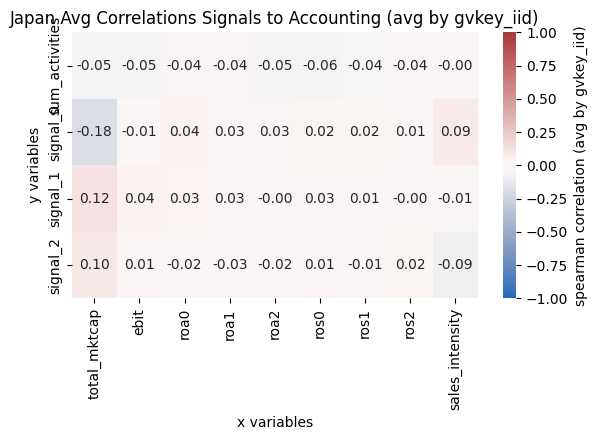

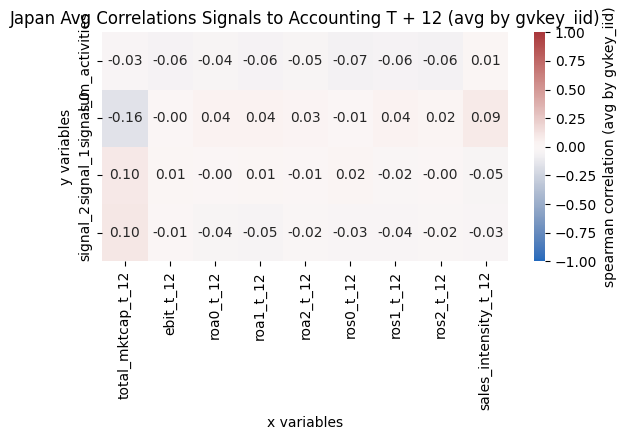

In [8]:
# Spearman avg correlation matrix by gvkey_iid (sorted by year)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def avg_corr_matrix_by_gvkey_iid(df, y_vars, x_vars, *, group_col="gvkey_iid", sort_col="year", method="spearman"):
    corr_cols = list(dict.fromkeys([*y_vars, *x_vars]))
    corr_mats = []
    for _, g in df.groupby(group_col, sort=False):
        g = g.sort_values(sort_col)
        data = g.loc[:, corr_cols].dropna(how="any")
        data = g
        if data.shape[0] < 2:
            continue
        corr_full = data.corr(method=method, numeric_only=True)
        corr_xy = corr_full.reindex(index=y_vars, columns=x_vars)
        corr_mats.append(corr_xy)

    if not corr_mats:
        raise ValueError(
            "No gvkey_iid groups had >=2 non-missing observations for the correlation matrix."
        )

    stack = np.stack([m.to_numpy() for m in corr_mats], axis=0)
    avg_vals = np.nanmean(stack, axis=0)
    return pd.DataFrame(avg_vals, index=y_vars, columns=x_vars)

def plot_corr_heatmap(corr_xy, *, method, title):
    figsize = (max(6.0, 0.6 * len(corr_xy.columns)), max(4.5, 0.45 * len(corr_xy.index)))
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        corr_xy,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        center=0.0,
        vmin=-1.0,
        vmax=1.0,
        square=False,
        cbar_kws={"label": f"{method} correlation (avg by gvkey_iid)"},
    )
    ax.set_xlabel("x variables")
    ax.set_ylabel("y variables")
    ax.set_title(title)
    fig.tight_layout()
    return ax


corr_xy = avg_corr_matrix_by_gvkey_iid(Japan_universe, signal_columns, accounting_columns, method="spearman")
plot_corr_heatmap(
    corr_xy,
    method="spearman",
    title="Japan Avg Correlations Signals to Accounting (avg by gvkey_iid)",
)

corr_xy = avg_corr_matrix_by_gvkey_iid(Japan_universe, signal_columns, accounting_columns_t, method="spearman")
plot_corr_heatmap(
    corr_xy,
    method="spearman",
    title="Japan Avg Correlations Signals to Accounting T + 12 (avg by gvkey_iid)",
)


In [9]:
corr_cols = list(dict.fromkeys([*signal_columns, *accounting_columns]))  # or accounting_columns_t
bad_rows = 0
zero_var = 0
used = 0

for iid, g in Japan_universe.groupby("gvkey_iid", sort=False):
    data = g.sort_values("year").loc[:, corr_cols].dropna(how="any")
    if data.shape[0] < 2:
        bad_rows += 1
        continue
    used += 1
    if data["sum_activities"].std(ddof=0) == 0:
        zero_var += 1

print("gvkey_iid groups skipped (<2 rows):", bad_rows)
print("gvkey_iid groups used:", used)
print("gvkey_iid used but sum_activities constant:", zero_var)

gvkey_iid groups skipped (<2 rows): 1
gvkey_iid groups used: 566
gvkey_iid used but sum_activities constant: 79
